# AeroDrift — Turbofan Engine Remaining Useful Life (RUL) Prediction

## Project Overview

**AeroDrift** predicts how many operational cycles remain before a turbofan engine requires maintenance, using the [NASA CMAPSS](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/) (Commercial Modular Aero-Propulsion System Simulation) dataset.

### Dataset — FD001
| Split | File | Description |
|---|---|---|
| Train | `train_FD001.txt` | Multi-variate time-series; each row is one engine cycle |
| Test  | `test_FD001.txt`  | Truncated sequences; we predict RUL at the last observed cycle |
| Labels| `RUL_FD001.txt`   | Ground-truth RUL for each test engine at its last cycle |

**Columns**
- `engine_id` — unique engine identifier (100 engines in FD001)
- `cycle` — operational cycle counter (time axis)
- `op1`, `op2`, `op3` — three operating-condition settings
- `sensor_1 … sensor_21` — 21 physical sensor measurements

### Problem Framing
This is a **regression** task: given sensor readings up to cycle *t*, predict the integer RUL (cycles remaining until end-of-life).

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import pandas as pd
import warnings
import os

from jupyter_core.migrate import regex

In [2]:
warnings.filterwarnings('ignore')

## 1. Data Loading

The raw files are whitespace-delimited with no header row. Trailing empty columns (artefacts of the format) are dropped immediately after reading.

In [3]:
import pandas as pd

cols = ['engine_id', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor_{i}' for i in range(1, 22)]

train = pd.read_csv('datasets/RUL/train_FD001.txt', sep=r'\s+', header=None, names=cols)
train = train.dropna(axis=1)  # removes trailing empty cols

test  = pd.read_csv('datasets/RUL/test_FD001.txt',  sep=r'\s+', header=None, names=cols)
test  = test.dropna(axis=1)

rul   = pd.read_csv('datasets/RUL/RUL_FD001.txt',   header=None, names=['RUL'])

## 2. RUL Label Construction

The training set contains **complete run-to-failure trajectories**, so we can derive the label directly from the data:

$$\text{RUL}(t) = \text{max\_cycle}_{\text{engine}} - t$$

At the very last observed cycle for each engine, RUL = 0 (failure). Earlier cycles carry larger RUL values, giving a linearly decreasing label.

In [4]:
# For each engine, RUL = (max_cycle - current_cycle)
max_cycles = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']
train = train.merge(max_cycles, on='engine_id')
train['RUL'] = train['max_cycle'] - train['cycle']

## 3. Exploratory Data Analysis

### 3.1 Dataset Shape & Types

Before doing anything else we inspect dimensionality, dtypes, and null counts. FD001 is a single operating-condition sub-dataset, so we expect relatively clean data.

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   op1        20631 non-null  float64
 3   op2        20631 non-null  float64
 4   op3        20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor_16  20631 

In [6]:
train.columns

Index(['engine_id', 'cycle', 'op1', 'op2', 'op3', 'sensor_1', 'sensor_2',
       'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8',
       'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13',
       'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
       'sensor_19', 'sensor_20', 'sensor_21', 'max_cycle', 'RUL'],
      dtype='str')

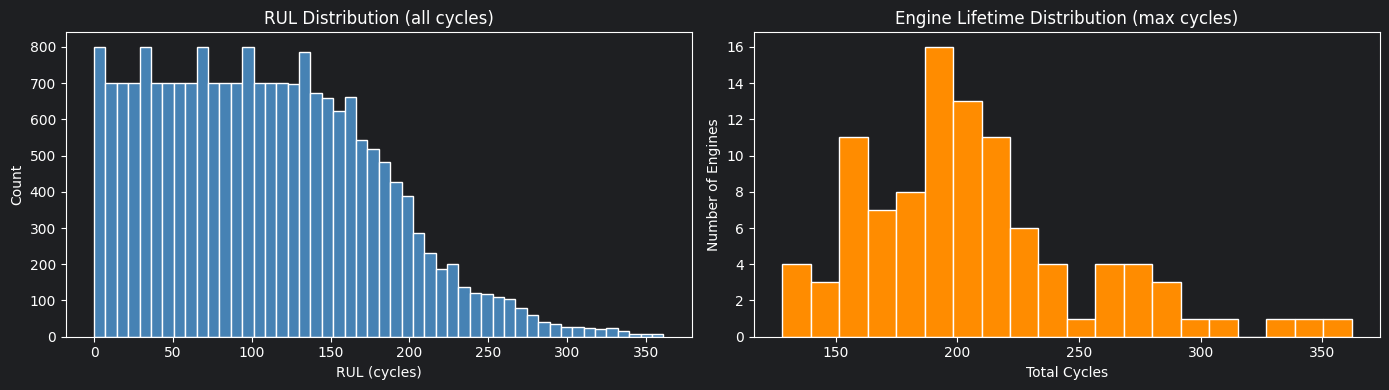

Engine lifetimes — min: 128, max: 362, mean: 206.3, median: 199.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RUL distribution across all training rows
axes[0].hist(train['RUL'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('RUL Distribution (all cycles)')
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Count')

# Engine lifetime distribution (how long each engine lived)
engine_lifetimes = train.groupby('engine_id')['max_cycle'].first()
axes[1].hist(engine_lifetimes, bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('Engine Lifetime Distribution (max cycles)')
axes[1].set_xlabel('Total Cycles')
axes[1].set_ylabel('Number of Engines')

plt.tight_layout()
plt.show()
print(f'Engine lifetimes — min: {engine_lifetimes.min()}, max: {engine_lifetimes.max()}, '
      f'mean: {engine_lifetimes.mean():.1f}, median: {engine_lifetimes.median()}')

**Observations:**
- The RUL histogram is approximately uniform over `[0, max_cycle]` for each engine — expected because we have full run-to-failure data and each engine contributes one row per cycle.
- Engine lifetimes vary considerably (roughly 130–370 cycles), meaning the model must generalise across engines with very different degradation speeds.

### 3.2 Operating Conditions

FD001 has a **single operating condition**, so `op1`, `op2`, `op3` should be constant (or near-constant). We verify this before removing zero-variance columns.

In [8]:
print('Operating condition stats:')
print(train[['op1', 'op2', 'op3']].describe().T[['mean', 'std', 'min', 'max']])

Operating condition stats:
           mean       std       min       max
op1   -0.000009  0.002187   -0.0087    0.0087
op2    0.000002  0.000293   -0.0006    0.0006
op3  100.000000  0.000000  100.0000  100.0000


### 3.3 Removing Zero-Variance (Constant) Features

Sensors or operating-condition columns whose standard deviation is effectively zero carry **no information** for the model — every value is the same regardless of engine health. We use `np.isclose(std, 0)` to robustly detect these and drop them.

In [9]:
mask = ~np.isclose(train.std(numeric_only=True), 0, atol=1e-8)
train = train.loc[:, mask]

### 3.4 Feature–Target Correlation

We compute the **absolute Pearson correlation** of every remaining feature with `RUL`. High-correlation features are the most directly informative candidates for the model. Low-correlation features can be noise and may be candidates for removal in a later step.

In [10]:
rul_corr = train.corr()['RUL'].drop('RUL').abs().sort_values(ascending=False)

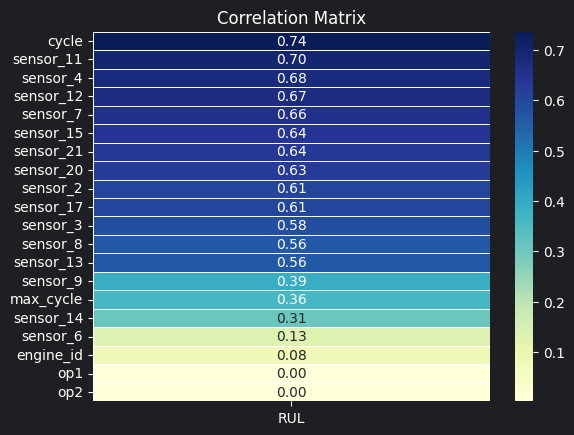

In [11]:
plt.figure()
sns.heatmap(rul_corr.to_frame(),
            annot=True,
            linewidths=0.5,
            fmt= ".2f",
            cmap="YlGnBu");
plt.title('Correlation Matrix');
plt.show()

The heatmap above shows absolute correlations with RUL. Let's rank them more clearly with a bar chart and identify the most and least informative features.

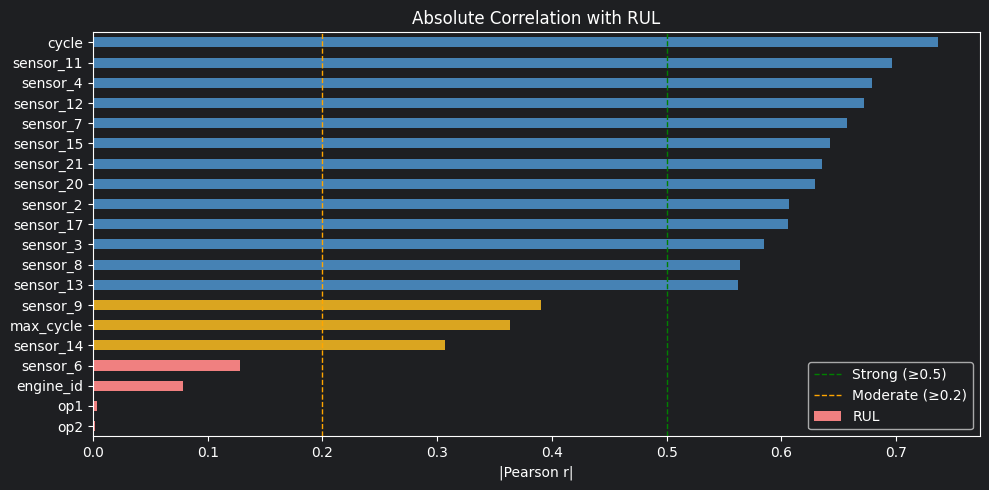


Top 5 features by correlation with RUL:
cycle        0.736241
sensor_11    0.696228
sensor_4     0.678948
sensor_12    0.671983
sensor_7     0.657223
Name: RUL, dtype: float64

Bottom 5 (least correlated):
sensor_14    0.306769
sensor_6     0.128348
engine_id    0.078753
op1          0.003198
op2          0.001948
Name: RUL, dtype: float64


In [12]:
plt.figure(figsize=(10, 5))
rul_corr.sort_values().plot(kind='barh', color=[
    'steelblue' if v >= 0.5 else ('goldenrod' if v >= 0.2 else 'lightcoral')
    for v in rul_corr.sort_values()
])
plt.axvline(0.5, color='green', linestyle='--', linewidth=1, label='Strong (≥0.5)')
plt.axvline(0.2, color='orange', linestyle='--', linewidth=1, label='Moderate (≥0.2)')
plt.title('Absolute Correlation with RUL')
plt.xlabel('|Pearson r|')
plt.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 features by correlation with RUL:')
print(rul_corr.head())
print('\nBottom 5 (least correlated):')
print(rul_corr.tail())

**Conclusion:** Sensors such as `sensor_11`, `sensor_4`, `sensor_12`, and `sensor_7` show the strongest monotonic relationship with RUL — they trend steadily as the engine degrades. Sensors near zero correlation (e.g. `sensor_1`, `sensor_5`) are essentially flat across the engine's life.

### 3.5 Inter-Sensor Multicollinearity

Highly correlated feature pairs (|r| > 0.9) add **redundant information** and can destabilise linear models or inflate feature-importance scores in tree-based ones. We compute the upper triangle of the sensor correlation matrix and drop one column from each highly correlated pair.

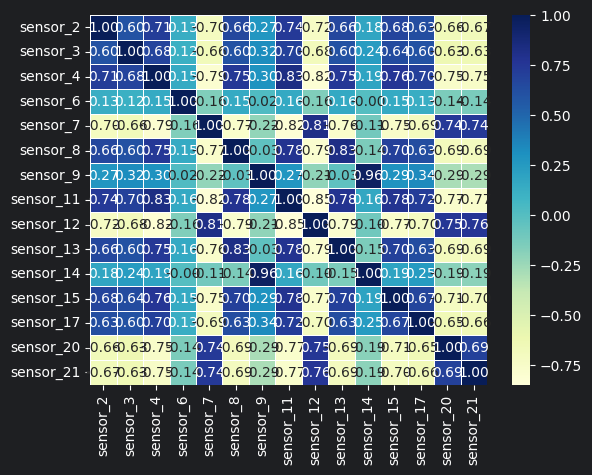

In [13]:
sensor_corr = train.filter(regex='^sensor_').corr()
sns.heatmap(sensor_corr,
            annot=True,
            linewidths=0.5,
            fmt= ".2f",
            cmap="YlGnBu");
upper = sensor_corr.where(np.triu(np.ones(sensor_corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(abs(upper[col]) > 0.9)]
train = train.drop(columns=to_drop)

**What was dropped?** After removing zero-variance columns earlier, and now dropping one from each pair with |r| > 0.9, the final feature set keeps only sensors that are both informative and non-redundant.

In [14]:
kept = [c for c in train.columns if c.startswith('sensor_')]
print(f'Sensors retained after multicollinearity pruning ({len(kept)}): {kept}')

Sensors retained after multicollinearity pruning (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


### 3.6 Aligning Test Columns with Train

The test set must contain exactly the same feature columns (in the same order) as the training set, excluding `RUL` and `max_cycle` (which are labels, not features).

In [15]:
test = test[train.drop(columns=['RUL', 'max_cycle']).columns]

In [16]:
train.columns, test.columns

(Index(['engine_id', 'cycle', 'op1', 'op2', 'sensor_2', 'sensor_3', 'sensor_4',
        'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
        'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20',
        'sensor_21', 'max_cycle', 'RUL'],
       dtype='str'),
 Index(['engine_id', 'cycle', 'op1', 'op2', 'sensor_2', 'sensor_3', 'sensor_4',
        'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
        'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20',
        'sensor_21'],
       dtype='str'))

### 3.7 Temporal Sensor Drift

The core hypothesis of this dataset is that sensor readings **drift monotonically** as an engine degrades — some increase, some decrease. Visualising this for a single engine helps confirm that the sensors carry genuine degradation signal.

Below we plot `sensor_11` and `sensor_4` for **Engine 1** on a dual y-axis (they have different scales). `sensor_11` is known to rise with degradation; `sensor_4` also trends upward.

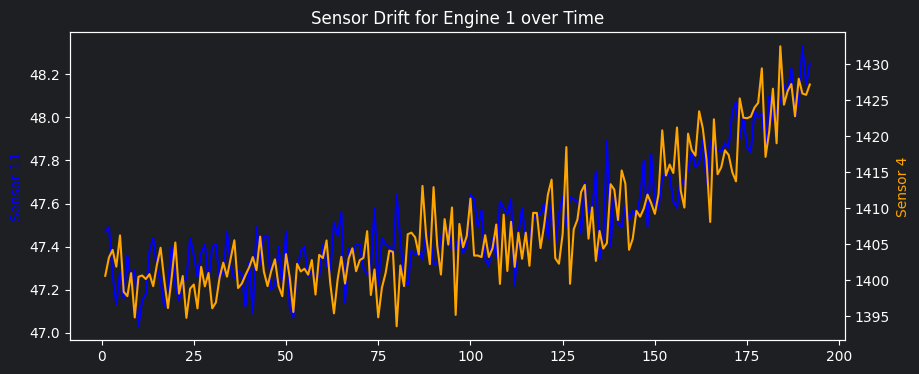

In [17]:
engine_1 = train[train['engine_id'] == 1]

plt.figure(figsize=(10, 4))

# Sensor 11
plt.plot(engine_1['cycle'], engine_1['sensor_11'], label='Sensor 11', color='blue')
plt.ylabel('Sensor 11', color='blue')

# Twin axis for Sensor 4
ax2 = plt.twinx()
ax2.plot(engine_1['cycle'], engine_1['sensor_4'], label='Sensor 4', color='orange')
ax2.set_ylabel('Sensor 4', color='orange')

plt.title('Sensor Drift for Engine 1 over Time')
plt.show()

### 3.8 Degradation Trends Across Multiple Engines

A single engine could be atypical. We overlay the top correlated sensor (`sensor_11`) for a sample of engines to verify that the trend is **consistent** and that the data is not dominated by one anomalous engine.

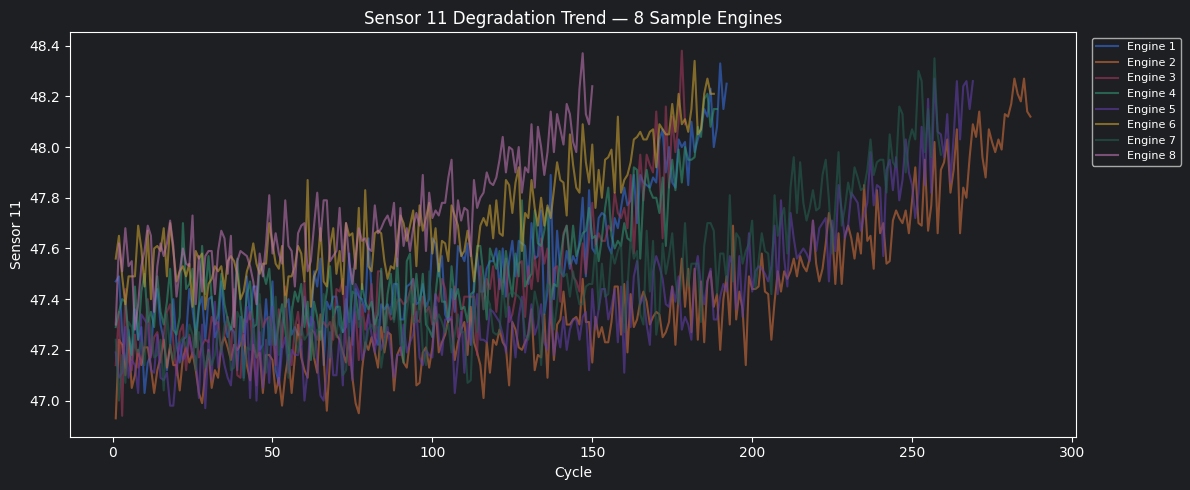

In [18]:
sample_engines = train['engine_id'].unique()[:8]
fig, ax = plt.subplots(figsize=(12, 5))

for eid in sample_engines:
    eng = train[train['engine_id'] == eid].sort_values('cycle')
    ax.plot(eng['cycle'], eng['sensor_11'], alpha=0.6, label=f'Engine {eid}')

ax.set_title('Sensor 11 Degradation Trend — 8 Sample Engines')
ax.set_xlabel('Cycle')
ax.set_ylabel('Sensor 11')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Observation:** `sensor_11` rises consistently across all sampled engines, confirming a systematic degradation signal rather than engine-specific noise. The different total lengths (x-axis) reflect the varying engine lifetimes we saw earlier.

### 3.9 Smoothed Sensor Signal (Rolling Mean)

Raw sensor readings can be noisy. A **rolling mean** (window = 10 cycles) helps distinguish the underlying degradation trend from cycle-to-cycle measurement noise, which is important when deciding whether to apply smoothing as a preprocessing step.

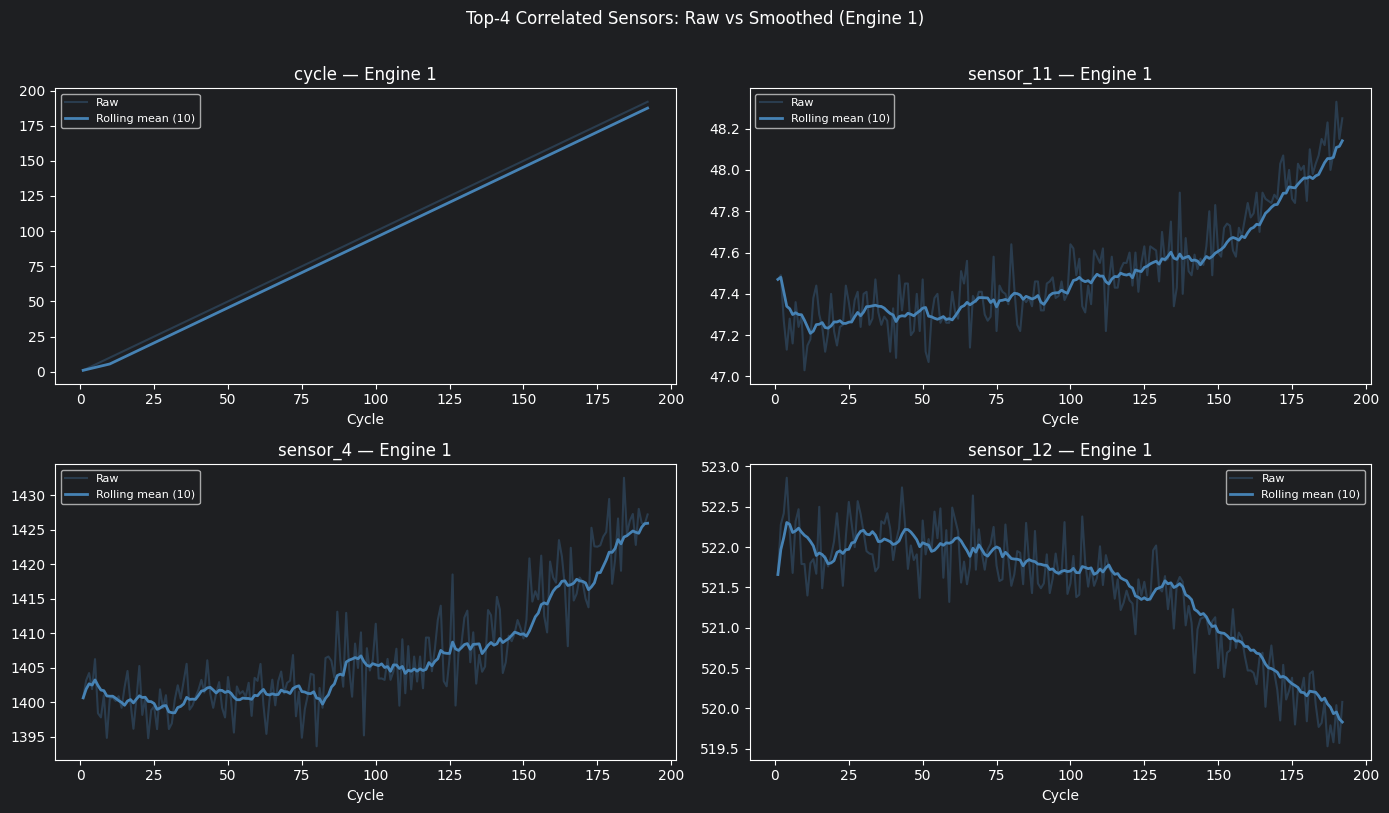

In [19]:
engine_1 = train[train['engine_id'] == 1].sort_values('cycle').copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
top_sensors = rul_corr.head(4).index.tolist()

for ax, sensor in zip(axes.flat, top_sensors):
    raw = engine_1[sensor]
    rolled = raw.rolling(10, min_periods=1).mean()
    ax.plot(engine_1['cycle'], raw, alpha=0.3, color='steelblue', label='Raw')
    ax.plot(engine_1['cycle'], rolled, color='steelblue', linewidth=2, label='Rolling mean (10)')
    ax.set_title(f'{sensor} — Engine 1')
    ax.set_xlabel('Cycle')
    ax.legend(fontsize=8)

plt.suptitle('Top-4 Correlated Sensors: Raw vs Smoothed (Engine 1)', y=1.01)
plt.tight_layout()
plt.show()

**Observation:** The rolling mean smooths out high-frequency noise while preserving the long-term drift trend. The signal-to-noise ratio varies by sensor — some (e.g. `sensor_12`) are already quite clean, while others benefit more from smoothing. Whether to apply smoothing before modelling depends on the model type and is worth experimenting with.

## 4. EDA Summary & Next Steps

| Step | Action | Outcome |
|---|---|---|
| Zero-variance removal | Dropped constant columns | Reduced feature noise |
| Target correlation | Ranked features by |r| with RUL | Identified most informative sensors |
| Multicollinearity pruning | Dropped sensors with inter-correlation > 0.9 | Removed redundant features |
| Test alignment | Matched test columns to train | Ready for inference |

**Retained features:** `engine_id`, `cycle`, `op1`, `op2`, plus a pruned set of sensors.

**Key findings:**
- Engine lifetimes span ~130–370 cycles — the model needs to handle this variability.
- `sensor_11`, `sensor_4`, `sensor_12`, and `sensor_7` are the strongest degradation indicators.
- Sensor signals show consistent monotonic drift across engines, validating the dataset quality.
- Some sensors are near-constant (zero variance) and carry zero information — safely removed.

**Next steps:**
1. Feature scaling (StandardScaler / MinMaxScaler)
2. Optional: piecewise-linear RUL cap (clip RUL at a threshold, e.g. 125 cycles)
3. Model training — baseline: Ridge/SVR; advanced: LSTM or Transformer on the full sequence
4. Evaluation: RMSE and the NASA scoring function (asymmetric, penalises late predictions more)